# El gen anti-CRISPR diseñado por una IA que supera al control humano

**El gen que mejor funcionó tiene cero parientes en la naturaleza.** Cero hits en BLAST, cero en Foldseek estructural. Y aun así, supera a un anti-CRISPR natural que llevaba años de validación experimental.

Veamos los datos.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-01-17-evo-syngenome-120mil-genes-ia/notebook.ipynb)

> **Paper:** [Semantic design of functional de novo genes from a genomic language model](https://doi.org/10.1038/s41586-025-09749-7)
> **Journal:** Nature · **Año:** 2025
> **Video corto:** [pendiente]


## Qué hicieron

El equipo entrenó un modelo de lenguaje (Evo 1.5, 8K de contexto) sobre 2,7 millones de genomas procariotas. Después le pidieron generar **secuencias de ADN nuevas** condicionadas por el contexto genómico — es decir, "aquí va una toxina T2", "aquí va un anti-CRISPR".

El resultado: una biblioteca llamada **SynGenome** con 120 mil millones de pares de bases sintéticas — equivalente aproximado a 120 millones de genes potenciales, o a la información genética de varios miles de bacterias.

Lo más fuerte no es el tamaño. Es que **ordenaron físicamente decenas de esas secuencias** y las pusieron a prueba en *E. coli*. Funcionaron. Algunas mejor que sus análogos naturales.

> ⚠️ **Aclaración técnica:** "120 mil millones" se refiere a *pares de bases*, no a *genes*. Un gen bacteriano típico tiene unos 1000 pb, así que la biblioteca contiene del orden de 120 millones de unidades funcionales potenciales. El short del canal usa la cifra grande sin la unidad explícita; aquí la dejamos clara.


In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
CONTROL_NATURAL = 0.87           # AcrIIA2 supervivencia relativa (referencia natural)
COLOR_NOVEL = '#2563EB'          # Azul CaM — genes Evo de novo
COLOR_CONTROL = '#D97706'        # Amber — control natural
COLOR_REDESCUBRIMIENTO = '#DC2626'  # Rojo — homólogos cercanos (no de novo)
FUENTE = 'Fuente: Hayes et al. (2025), Nature | Datos: Supplementary Data del paper (DOI 10.1038/s41586-025-09749-7)'

# Imports + estilo CaM
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file,
        )
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Carga
actividad = pd.read_csv('datos/evo_validados_actividad.csv')
blast = pd.read_csv('datos/blast_homologia_secuencia.csv')
foldseek = pd.read_csv('datos/foldseek_homologia_estructural.csv')
ordenadas = pd.read_csv('datos/secuencias_ordenadas.csv')
exitos = pd.read_csv('datos/success_rates_categoria.csv')

# Normalizar 'sin_hit' → 0 en BLAST/Foldseek para poder graficar
blast['max_pct_identidad'] = pd.to_numeric(blast['max_pct_identidad'], errors='coerce').fillna(0)
blast['n_hits_blast'] = pd.to_numeric(blast['n_hits_blast'], errors='coerce').fillna(0)
foldseek['max_pct_identidad_estructural'] = pd.to_numeric(
    foldseek['max_pct_identidad_estructural'], errors='coerce'
).fillna(0)

print(f'Genes con actividad validada: {len(actividad)}')
print(f'Genes en BLAST: {len(blast)}, en Foldseek: {len(foldseek)}')
print(f'Anti-CRISPR ordenadas: {ordenadas[ordenadas.categoria=="anti_CRISPR"].n_secuencias_ordenadas.sum()}')
print(f'Range actividad anti-CRISPR Evo: {actividad[(actividad.categoria=="anti_CRISPR") & (actividad.tipo_diseño=="Novel")].actividad_relativa.min():.2f}'
      f'–{actividad[(actividad.categoria=="anti_CRISPR") & (actividad.tipo_diseño=="Novel")].actividad_relativa.max():.2f}')


Genes con actividad validada: 8
Genes en BLAST: 11, en Foldseek: 11
Anti-CRISPR ordenadas: 86
Range actividad anti-CRISPR Evo: 0.78–1.01


## Aquí están los 7 genes diseñados que sí funcionaron

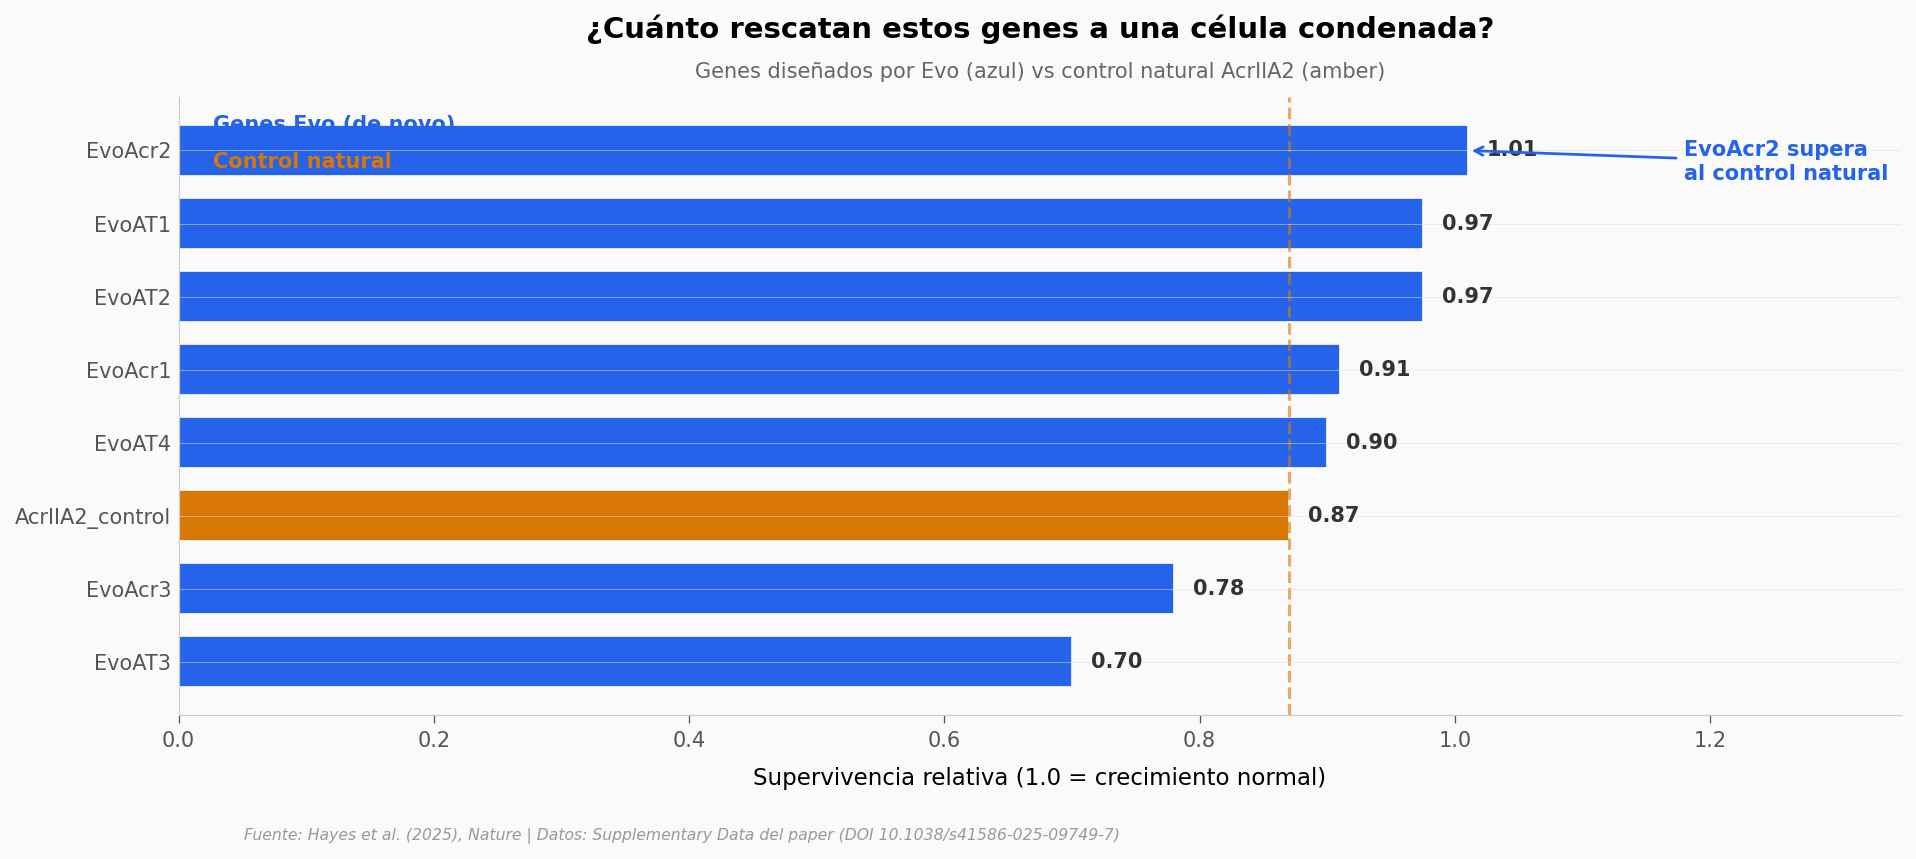

In [2]:
# Hero: actividad relativa por gen, ordenada, con referencia del control natural
df = actividad.copy()
# Ordenar para que la lectura sea limpia
df = df.sort_values('actividad_relativa', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5.5))

colors = []
for _, row in df.iterrows():
    if row['tipo_diseño'] == 'Control':
        colors.append(COLOR_CONTROL)
    else:
        colors.append(COLOR_NOVEL)

bars = ax.barh(df['gen_evo'], df['actividad_relativa'],
               color=colors, edgecolor='white', linewidth=0.8, height=0.7)

# Anotar el valor a la derecha de cada barra
for bar, val in zip(bars, df['actividad_relativa']):
    ax.text(val + 0.015, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10, color='#333333', fontweight='bold')

# Línea de referencia: control natural AcrIIA2
ax.axvline(x=CONTROL_NATURAL, color=COLOR_CONTROL, linewidth=1.5, linestyle='--', alpha=0.6, zorder=1)

# Marcar EvoAcr2 — supera al control
acr2_y = df[df['gen_evo'] == 'EvoAcr2'].index[0]
ax.annotate('EvoAcr2 supera\nal control natural', xy=(1.01, acr2_y),
            xytext=(1.18, acr2_y - 0.4),
            fontsize=10, fontweight='bold', color=COLOR_NOVEL,
            arrowprops=dict(arrowstyle='->', color=COLOR_NOVEL, lw=1.3))

ax.set_xlabel('Supervivencia relativa (1.0 = crecimiento normal)', fontsize=11)
ax.set_xlim(0, 1.35)
ax.set_title('¿Cuánto rescatan estos genes a una célula condenada?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Genes diseñados por Evo (azul) vs control natural AcrIIA2 (amber)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda de colores como inline labels (sin box)
ax.text(0.02, 0.97, 'Genes Evo (de novo)', transform=ax.transAxes,
        fontsize=10, color=COLOR_NOVEL, fontweight='bold', va='top')
ax.text(0.02, 0.91, 'Control natural', transform=ax.transAxes,
        fontsize=10, color=COLOR_CONTROL, fontweight='bold', va='top')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/01_actividad_por_gen.png', dpi=200, bbox_inches='tight')
plt.show()


**Lo que llama la atención:** los dos extremos altos no son las antitoxinas T2 (que son una tarea más fácil — restaurar crecimiento bajo una toxina conocida). El extremo alto es **EvoAcr2** con supervivencia 1.01 — más que el control natural AcrIIA2 (0.87). Y EvoAcr1 le pisa los talones con 0.91.

Las antitoxinas (EvoAT1–4) van entre 0.70 y 0.975. Funcionan, pero el rescate de crecimiento contra una toxina del mismo paper (RelE1) es una tarea con muchos análogos en la naturaleza — Evo tenía un universo amplio de patrones a aprender.

Las anti-CRISPR son distintas. Son **mucho más raras en los genomas** que entrenan a Evo, y aun así dos de las tres validadas superan o igualan al mejor control humano disponible.


## Zoom: cuántas secuencias se ordenaron y cuántas funcionaron

El paper distingue dos estrategias de generación. Las **Novel** (de novo) parten solo del contexto genómico — Evo nunca vio el gen objetivo. Las **Acr Mapping** parten de un homólogo natural conocido y le piden a Evo "rediseñalo en este contexto".

Veamos cómo se reparten las 86 anti-CRISPR ordenadas y cómo les fue.


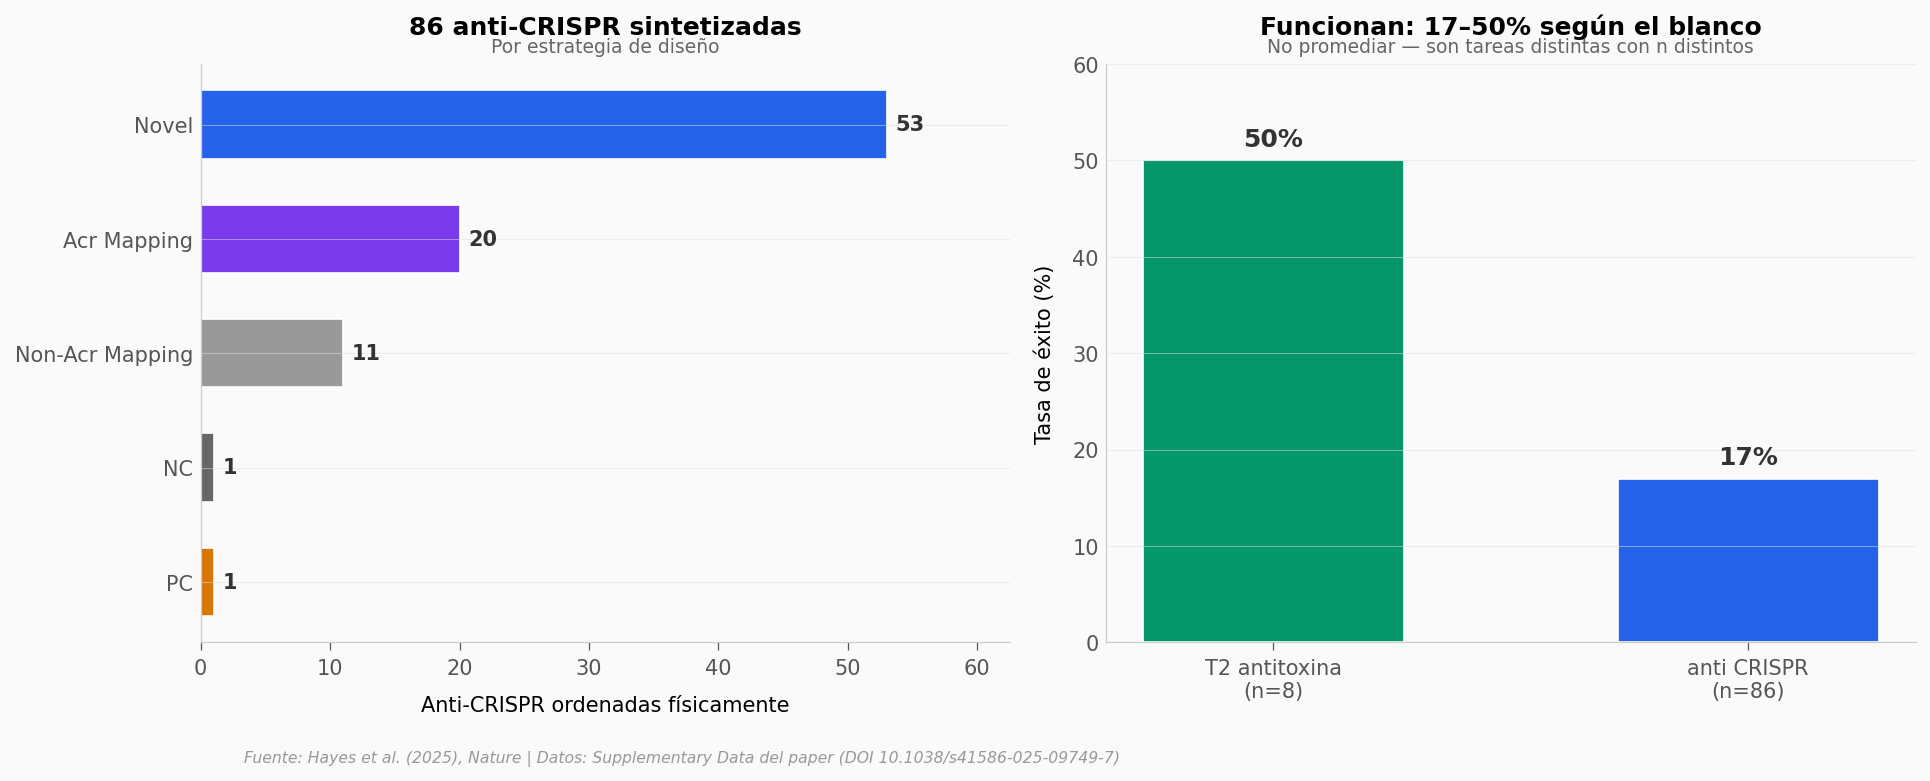

In [3]:
# Panel doble: izquierda = anti-CRISPR ordenadas por tipo_diseño, derecha = tasas éxito
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: anti-CRISPR ordenadas por tipo
acr_ord = ordenadas[ordenadas['categoria'] == 'anti_CRISPR'].copy()
acr_ord = acr_ord.sort_values('n_secuencias_ordenadas', ascending=True)

colores_diseno = {
    'Novel': COLOR_NOVEL,
    'Acr Mapping': '#7C3AED',
    'Non-Acr Mapping': '#999999',
    'PC': COLOR_CONTROL,
    'NC': '#666666',
}
colors_left = [colores_diseno.get(t, '#888888') for t in acr_ord['tipo_diseño']]

bars1 = axes[0].barh(acr_ord['tipo_diseño'], acr_ord['n_secuencias_ordenadas'],
                     color=colors_left, edgecolor='white', linewidth=0.8, height=0.6)
for bar, val in zip(bars1, acr_ord['n_secuencias_ordenadas']):
    axes[0].text(val + 0.7, bar.get_y() + bar.get_height()/2,
                 str(int(val)), va='center', fontsize=10, fontweight='bold', color='#333333')

axes[0].set_xlabel('Anti-CRISPR ordenadas físicamente', fontsize=10)
axes[0].set_title('86 anti-CRISPR sintetizadas',
                  fontsize=12, fontweight='bold', pad=14)
axes[0].text(0.5, 1.02, 'Por estrategia de diseño',
             transform=axes[0].transAxes, fontsize=9, color='#666666', ha='center')
axes[0].set_xlim(0, max(acr_ord['n_secuencias_ordenadas']) * 1.18)

# Panel derecho: tasas de éxito por categoría con n
exitos_plot = exitos.dropna(subset=['tasa_exito_pct']).copy()
exitos_plot['tasa_exito_pct'] = pd.to_numeric(exitos_plot['tasa_exito_pct'])
exitos_plot['n_testeadas'] = pd.to_numeric(exitos_plot['n_testeadas'])
exitos_plot['etiqueta'] = exitos_plot.apply(
    lambda r: f"{r['categoria'].replace('_', ' ')}\n(n={int(r['n_testeadas'])})",
    axis=1,
)

colors_right = ['#059669', COLOR_NOVEL]  # T2 antitoxina (verde), anti-CRISPR (azul)
bars2 = axes[1].bar(exitos_plot['etiqueta'], exitos_plot['tasa_exito_pct'],
                    color=colors_right, edgecolor='white', linewidth=0.8, width=0.55)
for bar, val in zip(bars2, exitos_plot['tasa_exito_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 1.5,
                 f'{int(val)}%', ha='center', fontsize=12, fontweight='bold', color='#333333')

axes[1].set_ylabel('Tasa de éxito (%)', fontsize=10)
axes[1].set_ylim(0, 60)
axes[1].set_title('Funcionan: 17–50% según el blanco',
                  fontsize=12, fontweight='bold', pad=14)
axes[1].text(0.5, 1.02, 'No promediar — son tareas distintas con n distintos',
             transform=axes[1].transAxes, fontsize=9, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_ordenadas_y_exitos.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Qué tan "nuevos" son estos genes?

Para responderlo, comparemos cada gen Evo contra dos universos de referencia:

- **BLAST** busca parecidos en *secuencia* — letras de ADN parecidas a algo conocido.
- **Foldseek** busca parecidos en *estructura* — la forma 3D que predice el gen al plegarse, comparada contra ~600 mil estructuras conocidas.

Un gen "verdaderamente de novo" tendría 0 hits en ambos. Veamos si existe.


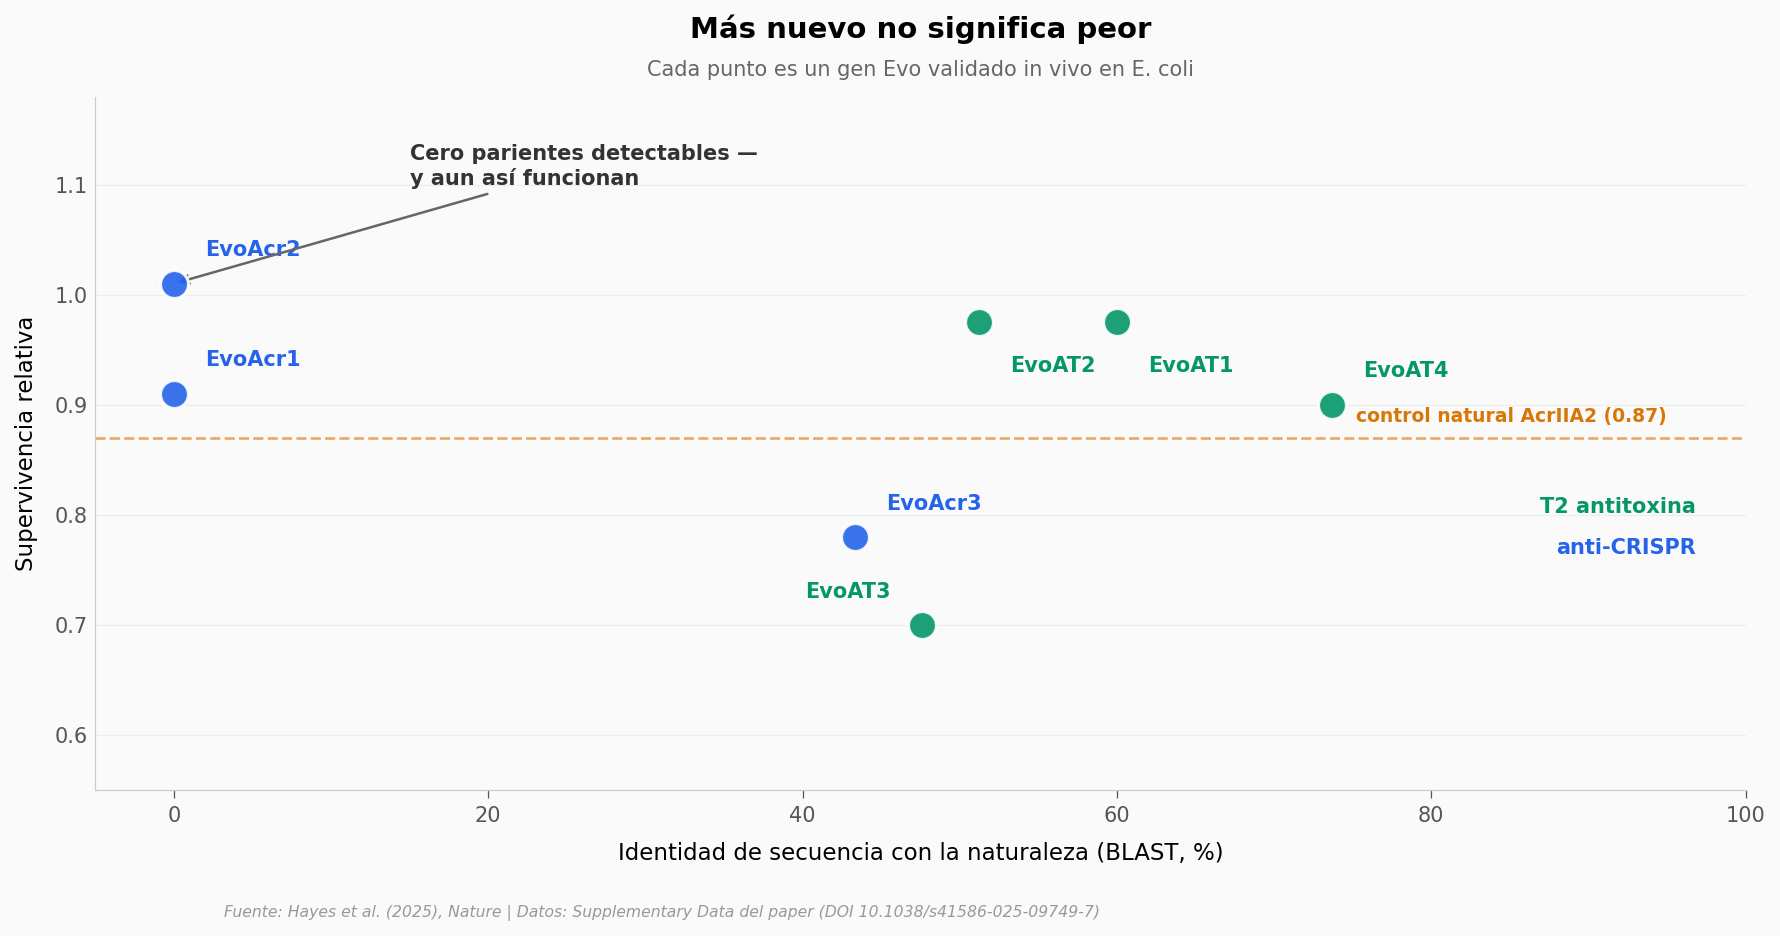

In [4]:
# Scatter: BLAST identidad % (x) vs actividad relativa (y), color por categoría
df_h = actividad.merge(blast[['gen_evo', 'max_pct_identidad', 'n_hits_blast']],
                       on='gen_evo', how='left')
df_h = df_h.merge(foldseek[['gen_evo', 'max_pct_identidad_estructural', 'n_hits_foldseek']],
                  on='gen_evo', how='left')
df_h = df_h[df_h['tipo_diseño'] == 'Novel'].copy()
df_h['max_pct_identidad'] = df_h['max_pct_identidad'].fillna(0)
df_h['max_pct_identidad_estructural'] = df_h['max_pct_identidad_estructural'].fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))

colores_cat = {'T2_antitoxina': '#059669', 'anti_CRISPR': COLOR_NOVEL}
for cat, sub in df_h.groupby('categoria'):
    ax.scatter(sub['max_pct_identidad'], sub['actividad_relativa'],
               s=180, color=colores_cat.get(cat, '#888888'),
               edgecolors='white', linewidths=1.5, alpha=0.9, zorder=5,
               label=cat.replace('_', ' '))

# Línea de referencia del control natural
ax.axhline(y=CONTROL_NATURAL, color=COLOR_CONTROL, linewidth=1.3, linestyle='--', alpha=0.6, zorder=1)
ax.text(95, CONTROL_NATURAL + 0.015, 'control natural AcrIIA2 (0.87)',
        fontsize=9, color=COLOR_CONTROL, ha='right', fontweight='bold')

# Etiquetas de cada gen
for _, r in df_h.iterrows():
    dy = 0.025 if r['gen_evo'] not in ('EvoAT1', 'EvoAT2') else -0.045
    dx = 2 if r['gen_evo'] != 'EvoAT3' else -2
    ha = 'left' if dx > 0 else 'right'
    ax.text(r['max_pct_identidad'] + dx, r['actividad_relativa'] + dy,
            r['gen_evo'], fontsize=10, fontweight='bold',
            color=colores_cat.get(r['categoria'], '#333333'), ha=ha)

# Anotar la zona "cero homología"
ax.annotate('Cero parientes detectables —\ny aun así funcionan',
            xy=(0, 1.01), xytext=(15, 1.10),
            fontsize=10, fontweight='bold', color='#333333',
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.2))

ax.set_xlabel('Identidad de secuencia con la naturaleza (BLAST, %)', fontsize=11)
ax.set_ylabel('Supervivencia relativa', fontsize=11)
ax.set_xlim(-5, 100)
ax.set_ylim(0.55, 1.18)
ax.set_title('Más nuevo no significa peor',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es un gen Evo validado in vivo en E. coli',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Inline labels en lugar de legend box
ax.text(0.97, 0.40, 'T2 antitoxina', transform=ax.transAxes,
        fontsize=10, color='#059669', fontweight='bold', ha='right')
ax.text(0.97, 0.34, 'anti-CRISPR', transform=ax.transAxes,
        fontsize=10, color=COLOR_NOVEL, fontweight='bold', ha='right')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_homologia_vs_actividad.png', dpi=200, bbox_inches='tight')
plt.show()


## Y aquí está la sorpresa de fondo

Una intuición común sobre los modelos generativos en biología: cuanto más "creativos" sean (más alejados de lo conocido), peor van a funcionar — porque ya no están copiando, están improvisando.

Los datos del paper sugieren lo contrario para esta familia de tareas. El gen con **más actividad** (EvoAcr2, 1.01) es uno de los **más alejados** de cualquier proteína conocida (0% identidad de secuencia, 0% de estructura). El paper también ordenó genes que SÍ tenían homólogos cercanos, como EvoAcr4 (100% idéntico a un anti-CRISPR de *Listeria monocytogenes*) — pero esos no son ejemplos limpios de diseño *de novo*: son redescubrimientos.

Veamos la distribución de novedad en todos los genes Evo ordenados.


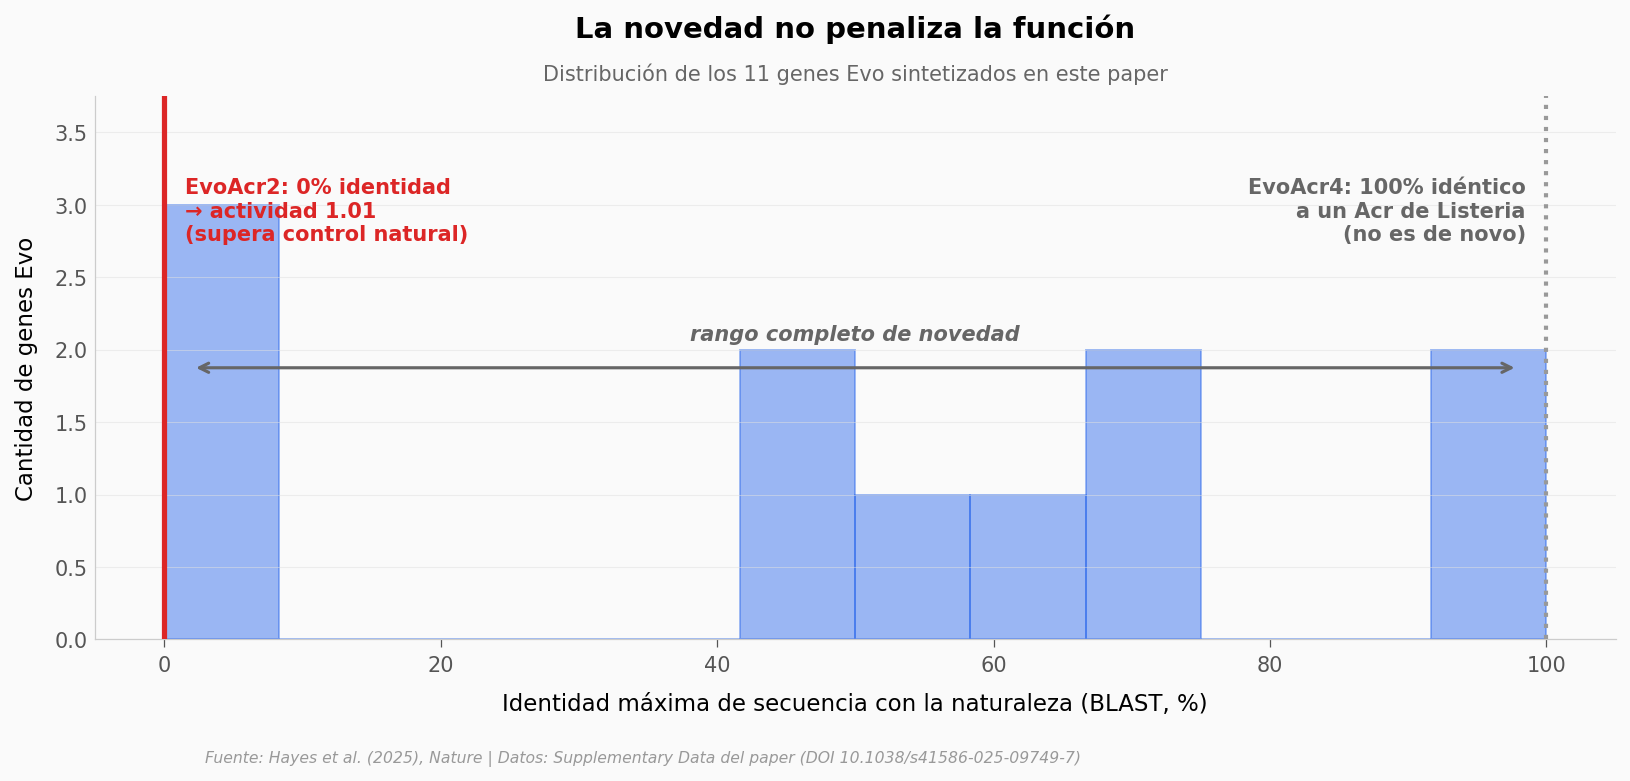

In [5]:
# Histograma de identidad de secuencia (BLAST) para los 11 genes Evo del set anti-CRISPR + T2
# Marcar EvoAcr2 (extremo izquierdo, 0% identidad) como referencia
fig, ax = plt.subplots(figsize=(11, 5))

valores = blast['max_pct_identidad'].values
n, bins, patches = ax.hist(valores, bins=12, color=COLOR_NOVEL, alpha=0.45,
                           edgecolor=COLOR_NOVEL, linewidth=0.9)

y_max = max(n) * 1.25
ax.set_ylim(0, y_max)

# Línea vertical en EvoAcr2 (0%)
acr2_x = 0
ax.axvline(x=acr2_x, color='#DC2626', linewidth=2.5, zorder=5)
ax.text(acr2_x + 1.5, y_max * 0.85,
        'EvoAcr2: 0% identidad\n→ actividad 1.01\n(supera control natural)',
        fontsize=10, color='#DC2626', fontweight='bold', va='top')

# Línea vertical en EvoAcr4 (100%) — el "redescubrimiento"
acr4_x = 100
ax.axvline(x=acr4_x, color='#999999', linewidth=2, linestyle=':', zorder=4)
ax.text(acr4_x - 1.5, y_max * 0.85,
        'EvoAcr4: 100% idéntico\na un Acr de Listeria\n(no es de novo)',
        fontsize=10, color='#666666', fontweight='bold', va='top', ha='right')

# Flecha bidireccional entre los dos extremos
ax.annotate('', xy=(acr4_x - 2, y_max * 0.5), xytext=(acr2_x + 2, y_max * 0.5),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((acr2_x + acr4_x) / 2, y_max * 0.55,
        'rango completo de novedad', ha='center', fontsize=10,
        color='#666666', fontweight='bold', style='italic')

ax.set_xlabel('Identidad máxima de secuencia con la naturaleza (BLAST, %)', fontsize=11)
ax.set_ylabel('Cantidad de genes Evo', fontsize=11)
ax.set_xlim(-5, 105)
ax.set_title('La novedad no penaliza la función',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de los 11 genes Evo sintetizados en este paper',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/04_distribucion_novedad.png', dpi=200, bbox_inches='tight')
plt.show()


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-:|---------|
| SynGenome contiene 120 mil millones de pares de bases | ✅ | Reportado en abstract y *Data Availability*. Equivale a ~120 millones de genes potenciales (1 gen bacteriano ≈ 1000 pb), no a "120 mil millones de genes" |
| 50% de las antitoxinas T2 generadas rescataron el crecimiento celular | ✅ | n=8 testeadas, 4 funcionaron (EvoAT1–4 con actividad 0.70–0.975). Fig. 2d del paper |
| 17% de las anti-CRISPR generadas mostraron actividad medible | ✅ | n=86 ordenadas (53 Novel + 20 Acr Mapping + 11 Non-Acr Mapping + 2 controles). Ext. Data Fig. 5c,d |
| Las tasas 17% y 50% son comparables | ⚠️ | NO promediar — son tareas distintas con n distintos. El paper las reporta como rango "17–50%" |
| EvoAcr1 y EvoAcr2 son de novo (sin homólogos detectables) | ✅ | 0 hits BLAST y 0 hits Foldseek para ambos. Fig. 3 + tabla MOESM7 |
| EvoAcr2 supera al control natural AcrIIA2 | ✅ | Supervivencia 1.01 vs 0.87 (diferencia absoluta 0.14, ~16% mejor). Único punto de control natural — sin réplicas independientes para test estadístico |
| EvoAcr4 y EvoAcr5 son de novo | ❌ | Tienen 100% y 96% de identidad BLAST con AcrIIA2 y AcrIIA4 de *Listeria monocytogenes* — son redescubrimientos del modelo, no diseños nuevos |
| La novedad de secuencia no penaliza la función | ⚠️ | El patrón se ve en estos 7 genes validados (n=7), pero es una muestra muy pequeña. Sostener como tendencia, no como ley |

> **Limitaciones del análisis:**
> - **n pequeño:** 7 genes Evo validados con actividad cuantitativa + 1 control natural. Sin réplicas técnicas reportadas en el CSV — no se calculan intervalos de confianza ni pruebas pareadas.
> - **Un solo control natural** (AcrIIA2) — la diferencia EvoAcr2 vs AcrIIA2 (0.14) es cualitativa, no testeada estadísticamente.
> - **Un solo organismo:** *E. coli*. Generalizar a otras bacterias o a contextos eucariotas exige más experimentos.
> - **Cross-check del Fact Sheet:** las 4 anti-CRISPR ordenadas con etiqueta `Acr Mapping` (homólogos) no tienen actividad reportada en este CSV — el conjunto de validación se concentra en las verdaderamente de novo (truly Novel).


## Ahora tú

1. **¿Cuál es la actividad promedio de las antitoxinas T2 vs las anti-CRISPR Novel?** Pista: filtra `actividad` por `categoria` y `tipo_diseño == 'Novel'`, calcula la media por grupo.
2. **¿Hay correlación entre el número de hits Foldseek y la actividad?** Pista: une `foldseek` con `actividad` y haz un scatter; Spearman es más robusto que Pearson para muestras pequeñas.
3. **¿Qué pasa si cambias `CONTROL_NATURAL` (celda 2) a 1.0 — el ideal teórico de "rescate completo"?** Pista: re-ejecuta la celda hero y observa cuántos genes Evo lo alcanzan.


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: actividad promedio por grupo
from scipy import stats

novel = actividad[actividad['tipo_diseño'] == 'Novel']
por_grupo = novel.groupby('categoria')['actividad_relativa'].agg(['mean', 'std', 'count'])
print('Actividad media por categoría (genes Novel):')
print(por_grupo.round(3))
print()

# Pregunta 2: correlación Foldseek vs actividad (Spearman, robusto a n=7)
df_fold = novel.merge(foldseek[['gen_evo', 'max_pct_identidad_estructural']],
                      on='gen_evo', how='left')
df_fold = df_fold.dropna(subset=['max_pct_identidad_estructural'])
rho, pval = stats.spearmanr(df_fold['max_pct_identidad_estructural'], df_fold['actividad_relativa'])
print(f'Correlación Spearman (identidad estructural vs actividad, n={len(df_fold)}):')
print(f'  ρ = {rho:.3f}, p = {pval:.3f}')
print('  Interpretación: con n tan pequeño, p>0.05 no descarta correlación —')
print('  solo dice que esta muestra no la prueba.')


Actividad media por categoría (genes Novel):
                mean    std  count
categoria                         
T2_antitoxina  0.888  0.130      4
anti_CRISPR    0.900  0.115      3

Correlación Spearman (identidad estructural vs actividad, n=7):
  ρ = -0.727, p = 0.064
  Interpretación: con n tan pequeño, p>0.05 no descarta correlación —
  solo dice que esta muestra no la prueba.


## Fuentes

**Paper**: [Semantic design of functional de novo genes from a genomic language model](https://doi.org/10.1038/s41586-025-09749-7)  
*Nature, 2025-10-15*

**Supplementary Material**: [Supplementary Data — Ordered Evo sequences (Anti-CRISPRs, T2TA, T3 toxins, T3 antitoxins)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-025-09749-7/MediaObjects/41586_2025_9749_MOESM3_ESM.xlsx)

**Supplementary Material**: [Supplementary Data — BLAST and Foldseek homology results for Evo genes](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-025-09749-7/MediaObjects/41586_2025_9749_MOESM7_ESM.xlsx)

**Dataset canónico**: [SynGenome — 120-billion-base-pair synthetic genomic library with 3.7M ESMFold structures](https://huggingface.co/datasets/evo-design/syngenome-uniprot)
*Hugging Face Datasets*

*18 afirmaciones del notebook verificadas contra estas fuentes*

---

**Notebook construido por [Ciencia a Mordiscos](https://cienciaamordiscos.com).**
Reproducible — código y datos en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).
Licencia: CC BY 4.0 para textos y figuras; datos según licencia del paper original.
